# 0. Imports

In [173]:
import numbers

import math
from tqdm import tqdm
from itertools import islice

import pandas as pd
import numpy as np

from river import (
    compose,
    preprocessing,
    tree,
    linear_model,
    forest,
    metrics,
    stream,
    stats,
    feature_extraction,
    imblearn,
    drift,
    cluster
)
from itertools import islice
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt

En River, el holdout se simula acumulando los primeros 70% de instancias para entrenamiento y el 30% restante para test.

# 1. Preparación offline

Vamos a trabajar sobre el dataset de weatherAUS ([link al dataset](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package)). Consiste en predecir si mañana lloverá o no a partir de una serie de datos. Cuenta con 10 años de registros de datos.

In [130]:
df = pd.read_csv('data/weatherAUS.csv')

In [131]:
print(df.shape)
print(df.dtypes)
print(df['RainTomorrow'].value_counts(normalize=True))

(145460, 23)
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object
RainTomorrow
No     0.775819
Yes    0.224181
Name: proportion, dtype: float64


In [132]:
print(df.isna().sum()/df.shape[0])

Date             0.000000
Location         0.000000
MinTemp          0.010209
MaxTemp          0.008669
Rainfall         0.022419
Evaporation      0.431665
Sunshine         0.480098
WindGustDir      0.070989
WindGustSpeed    0.070555
WindDir9am       0.072639
WindDir3pm       0.029066
WindSpeed9am     0.012148
WindSpeed3pm     0.021050
Humidity9am      0.018246
Humidity3pm      0.030984
Pressure9am      0.103568
Pressure3pm      0.103314
Cloud9am         0.384216
Cloud3pm         0.408071
Temp9am          0.012148
Temp3pm          0.024811
RainToday        0.022419
RainTomorrow     0.022460
dtype: float64


El dataset consta de valores nulos, incluso en la variable objetivo. Las filas con nulos en la variable objetivo se descartan. también se van a descartar las variables con un 40% de nulos. El resto de los datos serán tratados dentro del proceso online.

In [133]:
cols_to_drop = ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']

In [134]:
# Eliminamos las filas sin target:
df.drop(columns=cols_to_drop, inplace=True)

df = df.dropna(subset=['RainTomorrow', 'RainToday'])

df['RainToday'] = df['RainToday'].map({'Yes': 1, 'No': 0})
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [135]:
# Separamos las características (X) de la etiqueta (y)
X = df.drop(columns=['Date', 'RainTomorrow'])
y = df['RainTomorrow']


n_samples = len(df)

Con todo el dataset listo y el datastream preparado, ya podemos hacer la predicción online que se pide. En el pipeline de entrenamiento es donde se van a tratar los datos, ya que en la vida real no llegan datos limpios.

# Ejericio 1: Entrenamiento con holdout

Para el pipeline tenemos que separar las columnas en categóricas y numéricas ya que van a tener tratamientos distintos. 
En el pipeline se va a hacer una imputación de missings (por media en numéricas y moda en categóricas), después un escalado en numéricas y un OHE en categóricas. Además, para la variables de `Location` al tener muchos valores únicos se va a hacer un TargetEncoding.

In [8]:
train_size = int(n_samples * 0.70)

In [9]:
columnas_numericas = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 
    'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 
    'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday'
]

columnas_categoricas = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

In [10]:
# Creamos los imputadores pasándoles las tuplas generadas dinámicamente
# River recibirá: ('MinTemp', Mean()), ('MaxTemp', Mean()), etc.
imputador_num = preprocessing.StatImputer(*[(col, stats.Mean()) for col in columnas_numericas])
imputador_cat = preprocessing.StatImputer(*[(col, stats.Mode()) for col in columnas_categoricas])



# CONSTRUCCIÓN DE LAS RAMAS DEL PIPELINE


# RAMA 1: Location (Extraemos la probabilidad de lluvia de cada ciudad)
rama_location = feature_extraction.TargetAgg(
    by='Location',
    # how=stats.BayesianMean(prior=0.5, prior_weight=10)
    how=stats.Mean()
)

# RAMA 2: Resto de Categóricas (Filtramos -> Imputamos Nulos -> One-Hot)
rama_categorica = (
    compose.Select(*columnas_categoricas) | 
    imputador_cat | 
    preprocessing.OneHotEncoder()
)

# RAMA 3: Numéricas (Filtramos -> Imputamos Nulos -> Escalamos)
rama_numerica = (
    compose.Select(*columnas_numericas) | 
    imputador_num | 
    preprocessing.StandardScaler()
)


# PIPELINE FINAL

preprocesamiento = rama_location + rama_categorica + rama_numerica

In [ ]:
def build_preprocesamiento():
    imputador_num = preprocessing.StatImputer(*[(col, stats.Mean()) for col in columnas_numericas])
    imputador_cat = preprocessing.StatImputer(*[(col, stats.Mode()) for col in columnas_categoricas])
    rama_categoricas = (
    feature_extraction.TargetAgg(by='Location', how=stats.BayesianMean(prior=0.5, prior_weight=2)) +
    feature_extraction.TargetAgg(by='WindGustDir', how=stats.BayesianMean(prior=0.5, prior_weight=2)) +
    feature_extraction.TargetAgg(by='WindDir9am', how=stats.BayesianMean(prior=0.5, prior_weight=2)) +
    feature_extraction.TargetAgg(by='WindDir3pm', how=stats.BayesianMean(prior=0.5, prior_weight=2))
    )
    rama_numerica   = compose.Select(*columnas_numericas)   | imputador_num | preprocessing.StandardScaler()
    return  rama_categoricas + rama_numerica

In [66]:
modelo_1 = build_preprocesamiento() | imblearn.RandomUnderSampler(
    classifier=tree.HoeffdingAdaptiveTreeClassifier(
        grace_period=100,      
        leaf_prediction='nba', 
        seed=42
    ),
    desired_dist={0: 0.5, 1: 0.5}, # Forzamos a que el modelo aprenda 50/50
    seed=42
)

# MODELO 2: Adaptive Random Forest Balanceado
modelo_2 = build_preprocesamiento() | imblearn.RandomUnderSampler(
    classifier=forest.ARFClassifier(
    n_models=10,           
    lambda_value=2, 
    grace_period=200,   
    leaf_prediction='nba', 
    seed=42
    ),
    desired_dist={0: 0.5, 1: 0.5},
    seed=42
)

In [ ]:
## Los modelos 

# modelo_1 = build_preprocesamiento() | tree.HoeffdingAdaptiveTreeClassifier(
#     grace_period=200,
#     # delta=1e-5,
#     leaf_prediction='nba',   # Naive Bayes en hojas: mejor con desbalance
#     seed=42
# )
# modelo_2 = build_preprocesamiento() | forest.ARFClassifier(
#     n_models=10,           
#     lambda_value=2, 
#     grace_period=200,   
#     leaf_prediction='nba', 
#     seed=42
# )



In [67]:
dataset_stream = stream.iter_pandas(X, y)

In [ ]:
## Entrenamiento

for i, (x_i, y_i) in enumerate(
        tqdm(islice(dataset_stream, train_size), total=train_size)
    ):
    modelo_1.learn_one(x_i, y_i)
    modelo_2.learn_one(x_i, y_i)

100%|██████████| 98550/98550 [01:18<00:00, 1254.72it/s]


In [69]:
def inicializar_metricas():
    return {
        'Accuracy': metrics.Accuracy(),
        'Balanced_Accuracy': metrics.BalancedAccuracy(),
        'Kappa': metrics.CohenKappa(),
        'F1': metrics.F1(),
        'RocAuc': metrics.ROCAUC(),
        'Confusion_Matrix': metrics.ConfusionMatrix(),
        'Reporte_Completo': metrics.ClassificationReport() # Calcula Precision, Recall y F1 por clase
    }

metricas_m1 = inicializar_metricas()
metricas_m2 = inicializar_metricas()

# Estructuras para guardar los datos de las gráficas
historial_graficas = {
    'instancia': [],
    'm1_accuracy': [], 'm1_kappa': [], 'm1_f1': [], 'm1_rocauc': [],
    'm2_accuracy': [], 'm2_kappa': [], 'm2_f1': [], 'm2_rocauc': []
}

In [70]:
test_size = n_samples - train_size

for i, (x_i, y_i) in enumerate(
        tqdm(islice(dataset_stream, test_size), total=test_size)
    ):
    
    # 1. Realizar predicciones
    y_pred_1 = modelo_1.predict_one(x_i)
    y_pred_2 = modelo_2.predict_one(x_i)
    
    y_pred_proba_1 = modelo_1.predict_proba_one(x_i)
    y_pred_proba_2 = modelo_2.predict_proba_one(x_i)
    
    # 2. Actualizar las métricas (si la predicción no es nula, lo cual pasa al inicio pero aquí ya están entrenados)
    if y_pred_1 is not None:
        metricas_m1['Accuracy'].update(y_i, y_pred_1)
        metricas_m1['Balanced_Accuracy'].update(y_i, y_pred_1)
        metricas_m1['Kappa'].update(y_i, y_pred_1)
        metricas_m1['Reporte_Completo'].update(y_i, y_pred_1)
        metricas_m1['F1'].update(y_i, y_pred_1)
        metricas_m1['RocAuc'].update(y_i, y_pred_proba_1)
        metricas_m1['Confusion_Matrix'].update(y_i, y_pred_1)
        
    if y_pred_2 is not None:
        metricas_m2['Accuracy'].update(y_i, y_pred_2)
        metricas_m2['Balanced_Accuracy'].update(y_i, y_pred_2)
        metricas_m2['Kappa'].update(y_i, y_pred_2)
        metricas_m2['Reporte_Completo'].update(y_i, y_pred_2)
        metricas_m2['F1'].update(y_i, y_pred_2)
        metricas_m2['RocAuc'].update(y_i, y_pred_proba_2)
        metricas_m2['Confusion_Matrix'].update(y_i, y_pred_2)

    # 3. Guardar datos para gráficas (cada 500 iteraciones para no saturar la memoria ni el gráfico)
    if (i + 1) % 500 == 0:
        historial_graficas['instancia'].append(i + 1)
        historial_graficas['m1_accuracy'].append(metricas_m1['Accuracy'].get())
        historial_graficas['m1_kappa'].append(metricas_m1['Kappa'].get())
        historial_graficas['m1_f1'].append(metricas_m1['F1'].get())
        historial_graficas['m1_rocauc'].append(metricas_m1['RocAuc'].get())
        historial_graficas['m2_accuracy'].append(metricas_m2['Accuracy'].get())
        historial_graficas['m2_kappa'].append(metricas_m2['Kappa'].get())
        historial_graficas['m2_f1'].append(metricas_m2['F1'].get())
        historial_graficas['m2_rocauc'].append(metricas_m2['RocAuc'].get())

100%|██████████| 42237/42237 [00:34<00:00, 1211.40it/s]


In [71]:
# --- IMPRESIÓN DE RESULTADOS ---
for nombre, metricas in [("MODELO 1 (HOEFFDING TREE)", metricas_m1), ("MODELO 2 (ADAPTIVE RANDOM FOREST)", metricas_m2)]:
    print(f"\n=== RESULTADOS {nombre} ===")
    print(f"Accuracy: {metricas['Accuracy'].get():.4f}")
    print(f"ROC AUC:  {metricas['RocAuc'].get():.4f}")
    print(f"Kappa:    {metricas['Kappa'].get():.4f}")
    print("\nMatriz de Confusión:\n", metricas['Confusion_Matrix'])
    print("\nReporte por clases:\n", metricas['Reporte_Completo'])
    print("-" * 50)



=== RESULTADOS MODELO 1 (HOEFFDING TREE) ===
Accuracy: 0.6048
ROC AUC:  0.7141
Kappa:    0.2143

Matriz de Confusión:
     0        1       
0   18,609   14,405  
1    2,286    6,937  

Reporte por clases:
            Precision   Recall   F1       Support  
                                                  
       0      89.06%   56.37%   69.04%     33014  
       1      32.50%   75.21%   45.39%      9223  
                                                  
   Macro      60.78%   65.79%   57.22%            
   Micro      60.48%   60.48%   60.48%            
Weighted      76.71%   60.48%   63.87%            

                 60.48% accuracy                  
--------------------------------------------------

=== RESULTADOS MODELO 2 (ADAPTIVE RANDOM FOREST) ===
Accuracy: 0.7389
ROC AUC:  0.6907
Kappa:    0.2924

Matriz de Confusión:
     0        1      
0   26,467   6,547  
1    4,479   4,744  

Reporte por clases:
            Precision   Recall   F1       Support  
                 

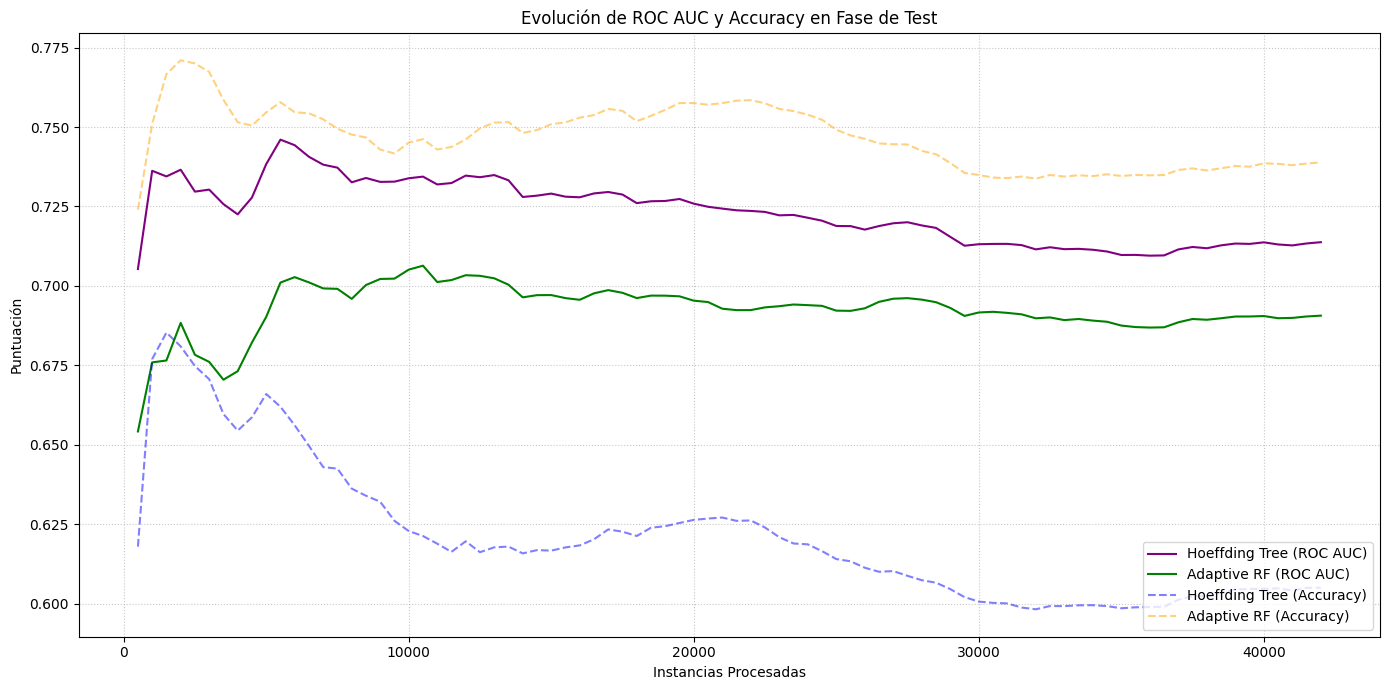

In [72]:
df_graficas = pd.DataFrame(historial_graficas)
plt.figure(figsize=(14, 7))

# Graficamos el ROC AUC
plt.plot(df_graficas['instancia'], df_graficas['m1_rocauc'], label='Hoeffding Tree (ROC AUC)', linestyle='-', color='purple')
plt.plot(df_graficas['instancia'], df_graficas['m2_rocauc'], label='Adaptive RF (ROC AUC)', linestyle='-', color='green')

# Graficamos el Accuracy (con transparencia para que no sature)
plt.plot(df_graficas['instancia'], df_graficas['m1_accuracy'], label='Hoeffding Tree (Accuracy)', linestyle='--', color='blue', alpha=0.5)
plt.plot(df_graficas['instancia'], df_graficas['m2_accuracy'], label='Adaptive RF (Accuracy)', linestyle='--', color='orange', alpha=0.5)

plt.title('Evolución de ROC AUC y Accuracy en Fase de Test')
plt.xlabel('Instancias Procesadas')
plt.ylabel('Puntuación')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Ejericio 2: Entrenamiento con prequential

In [73]:
modelo_1_pre = build_preprocesamiento() | imblearn.RandomUnderSampler(
    classifier=tree.HoeffdingAdaptiveTreeClassifier(
        grace_period=100,      
        leaf_prediction='nba', 
        seed=42
    ),
    desired_dist={0: 0.5, 1: 0.5}, # Forzamos a que el modelo aprenda 50/50
    seed=42
)

modelo_2_pre = build_preprocesamiento() | imblearn.RandomUnderSampler(
    classifier=forest.ARFClassifier(
    n_models=10,           
    lambda_value=2, 
    grace_period=200,   
    leaf_prediction='nba', 
    seed=42
    ),
    desired_dist={0: 0.5, 1: 0.5},
    seed=42
)

In [75]:
metricas_m1_pre = inicializar_metricas()
metricas_m2_pre = inicializar_metricas()

historial_graficas_pre = {
    'instancia': [],
    'm1_accuracy': [], 'm1_kappa': [], 'm1_f1': [], 'm1_rocauc': [],
    'm2_accuracy': [], 'm2_kappa': [], 'm2_f1': [], 'm2_rocauc': []
}

In [76]:
dataset_stream = stream.iter_pandas(X, y)

In [77]:
for i, (x, y_true) in enumerate(
        tqdm(islice(dataset_stream, n_samples), total=n_samples)
    ):
    
    # 1. FASE TEST (Evaluar antes de aprender)
    y_pred_1, y_prob_1 = modelo_1.predict_one(x), modelo_1.predict_proba_one(x)
    y_pred_2, y_prob_2 = modelo_2.predict_one(x), modelo_2.predict_proba_one(x)
    
    # Actualizar métricas:
    if y_pred_1 is not None:
        metricas_m1_pre['Accuracy'].update(y_true, y_pred_1)
        metricas_m1_pre['Balanced_Accuracy'].update(y_true, y_pred_1)
        metricas_m1_pre['Kappa'].update(y_true, y_pred_1)
        metricas_m1_pre['Reporte_Completo'].update(y_true, y_pred_1)
        metricas_m1_pre['F1'].update(y_true, y_pred_1)
        metricas_m1_pre['RocAuc'].update(y_true, y_prob_1)
        metricas_m1_pre['Confusion_Matrix'].update(y_true, y_pred_1)
    
    if y_pred_2 is not None:
        metricas_m2_pre['Accuracy'].update(y_true, y_pred_2)
        metricas_m2_pre['Balanced_Accuracy'].update(y_true, y_pred_2)
        metricas_m2_pre['Kappa'].update(y_true, y_pred_2)
        metricas_m2_pre['Reporte_Completo'].update(y_true, y_pred_2)
        metricas_m2_pre['F1'].update(y_true, y_pred_2)
        metricas_m2_pre['RocAuc'].update(y_true, y_prob_2)
        metricas_m2_pre['Confusion_Matrix'].update(y_true, y_pred_2)
        
    # 2. FASE TRAIN (Aprender de la misma instancia)
    modelo_1.learn_one(x, y_true)
    modelo_2.learn_one(x, y_true)
    
    # 3. Almacenar datos para gráficas cada 500 iteraciones
    if (i + 1) % 500 == 0:
        historial_graficas_pre['instancia'].append(i + 1)
        historial_graficas_pre['m1_accuracy'].append(metricas_m1_pre['Accuracy'].get())
        historial_graficas_pre['m1_kappa'].append(metricas_m1_pre['Kappa'].get())
        historial_graficas_pre['m1_f1'].append(metricas_m1_pre['F1'].get())
        historial_graficas_pre['m1_rocauc'].append(metricas_m1_pre['RocAuc'].get())
        historial_graficas_pre['m2_accuracy'].append(metricas_m2_pre['Accuracy'].get())
        historial_graficas_pre['m2_kappa'].append(metricas_m2_pre['Kappa'].get())
        historial_graficas_pre['m2_f1'].append(metricas_m2_pre['F1'].get())
        historial_graficas_pre['m2_rocauc'].append(metricas_m2_pre['RocAuc'].get())

100%|██████████| 140787/140787 [04:06<00:00, 571.37it/s]


In [81]:
# 4. Resultados
for nombre, metricas in [("MODELO 1 (HOEFFDING TREE)", metricas_m1_pre), ("MODELO 2 (ADAPTIVE RANDOM FOREST)", metricas_m2_pre)]:
    print(f"\n=== RESULTADOS {nombre} ===")
    print(f"Accuracy: {metricas['Accuracy'].get():.4f}")
    print(f"ROC AUC:  {metricas['RocAuc'].get():.4f}")
    print(f"Kappa:    {metricas['Kappa'].get():.4f}")
    print("\nMatriz de Confusión:\n", metricas['Confusion_Matrix'])
    print("\nReporte por clases:\n", metricas['Reporte_Completo'])
    print("-" * 50)


=== RESULTADOS MODELO 1 (HOEFFDING TREE) ===
Accuracy: 0.7057
ROC AUC:  0.7130
Kappa:    0.2885

Matriz de Confusión:
     0        1       
0   80,201   29,385  
1   12,042   19,159  

Reporte por clases:
            Precision   Recall   F1       Support  
                                                  
       0      86.95%   73.19%   79.47%    109586  
       1      39.47%   61.41%   48.05%     31201  
                                                  
   Macro      63.21%   67.30%   63.76%            
   Micro      70.57%   70.57%   70.57%            
Weighted      76.42%   70.57%   72.51%            

                 70.57% accuracy                  
--------------------------------------------------

=== RESULTADOS MODELO 2 (ADAPTIVE RANDOM FOREST) ===
Accuracy: 0.7166
ROC AUC:  0.7239
Kappa:    0.3000

Matriz de Confusión:
     0        1       
0   82,065   27,521  
1   12,381   18,820  

Reporte por clases:
            Precision   Recall   F1       Support  
              

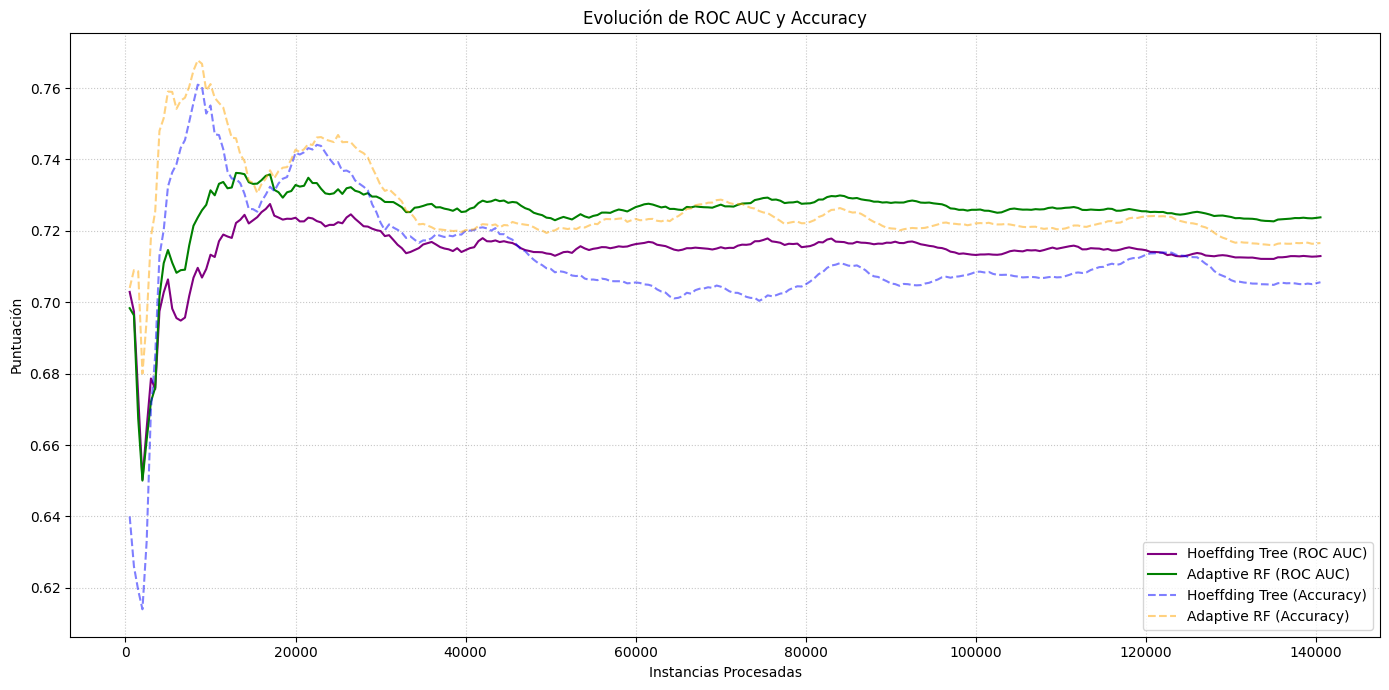

In [82]:
df_graficas_pre = pd.DataFrame(historial_graficas_pre)
plt.figure(figsize=(14, 7))

# Graficamos el ROC AUC
plt.plot(df_graficas_pre['instancia'], df_graficas_pre['m1_rocauc'], label='Hoeffding Tree (ROC AUC)', linestyle='-', color='purple')
plt.plot(df_graficas_pre['instancia'], df_graficas_pre['m2_rocauc'], label='Adaptive RF (ROC AUC)', linestyle='-', color='green')

# Graficamos el Accuracy (con transparencia para que no sature)
plt.plot(df_graficas_pre['instancia'], df_graficas_pre['m1_accuracy'], label='Hoeffding Tree (Accuracy)', linestyle='--', color='blue', alpha=0.5)
plt.plot(df_graficas_pre['instancia'], df_graficas_pre['m2_accuracy'], label='Adaptive RF (Accuracy)', linestyle='--', color='orange', alpha=0.5)

plt.title('Evolución de ROC AUC y Accuracy')
plt.xlabel('Instancias Procesadas')
plt.ylabel('Puntuación')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Observamos que los modelos entrenados en holdout se quedan obsoletos más rápido y el accuracy después de un tiempo cae mucho. SIn embargo, los modelos entrenados con prequential son más estables a lo largo del tiempo, aunque tardan un pequeño tiempo en conseguir unos resultados decentes, después logran ser muy estables en el tiempo.

# Ejericio 3: Conepto de deriva

In [83]:
modelo_drift = build_preprocesamiento() | imblearn.RandomUnderSampler(
    classifier=tree.HoeffdingAdaptiveTreeClassifier(
        grace_period=100,      
        leaf_prediction='nba', 
        seed=42
    ),
    desired_dist={0: 0.5, 1: 0.5}, # Forzamos a que el modelo aprenda 50/50
    seed=42
)

In [95]:
dataset_stream = stream.iter_pandas(X, y)

In [103]:
# ADWIN monitorizará los errores. Un delta menor hace que salte con menos frecuencia (solo cambios grandes).
detector = drift.ADWIN(delta=1e-5)

historial_accuracy = []
instancias_drifts = [] 

# Usamos una métrica de ventana móvil (últimas 2000 instancias) para ver la caída real en el momento
rolling_metric = metrics.Accuracy()
ventana = 2000

cooldown = 0 # Evita que salten 100 alertas seguidas por el mismo cambio climático

In [97]:
fechas = df['Date']

In [104]:
for i, (x, y_true) in enumerate(stream.iter_pandas(X, y)):
    
    y_pred = modelo_drift.predict_one(x)
    
    if y_pred is not None:
        rolling_metric.update(y_true, y_pred)
        
        # El detector recibe el error (0 acierto, 1 fallo)
        error = int(y_pred != y_true) 
        detector.update(error)
        
        # Solo comprobamos la deriva si no estamos en tiempo de enfriamiento
        if cooldown == 0 and detector.drift_detected:
            print(f"⚠️ DERIVA detectada en la instancia {i}")
            instancias_drifts.append(i)
            cooldown = 3000 # Esperamos 3000 instancias antes de volver a escuchar alarmas
            
    if cooldown > 0:
        cooldown -= 1
            
    modelo_drift.learn_one(x, y_true)
    
    # Guardamos el rolling accuracy cada 500 instancias
    if (i + 1) % 500 == 0:
        # Revertimos la métrica de River si necesitamos borrar el historial viejo
        # Aunque Rolling de River es mejor, aquí guardamos el valor actual
        historial_accuracy.append((i + 1, rolling_metric.get()))

⚠️ MACRO-DERIVA detectada en la instancia 2527
⚠️ MACRO-DERIVA detectada en la instancia 9215
⚠️ MACRO-DERIVA detectada en la instancia 15743
⚠️ MACRO-DERIVA detectada en la instancia 19967
⚠️ MACRO-DERIVA detectada en la instancia 25343
⚠️ MACRO-DERIVA detectada en la instancia 33663
⚠️ MACRO-DERIVA detectada en la instancia 37215
⚠️ MACRO-DERIVA detectada en la instancia 44031
⚠️ MACRO-DERIVA detectada en la instancia 49215
⚠️ MACRO-DERIVA detectada en la instancia 60383
⚠️ MACRO-DERIVA detectada en la instancia 65311
⚠️ MACRO-DERIVA detectada en la instancia 70687
⚠️ MACRO-DERIVA detectada en la instancia 75455
⚠️ MACRO-DERIVA detectada en la instancia 80159
⚠️ MACRO-DERIVA detectada en la instancia 83167
⚠️ MACRO-DERIVA detectada en la instancia 91455
⚠️ MACRO-DERIVA detectada en la instancia 96991
⚠️ MACRO-DERIVA detectada en la instancia 107487
⚠️ MACRO-DERIVA detectada en la instancia 111103
⚠️ MACRO-DERIVA detectada en la instancia 116223
⚠️ MACRO-DERIVA detectada en la instanc

<Figure size 640x480 with 0 Axes>

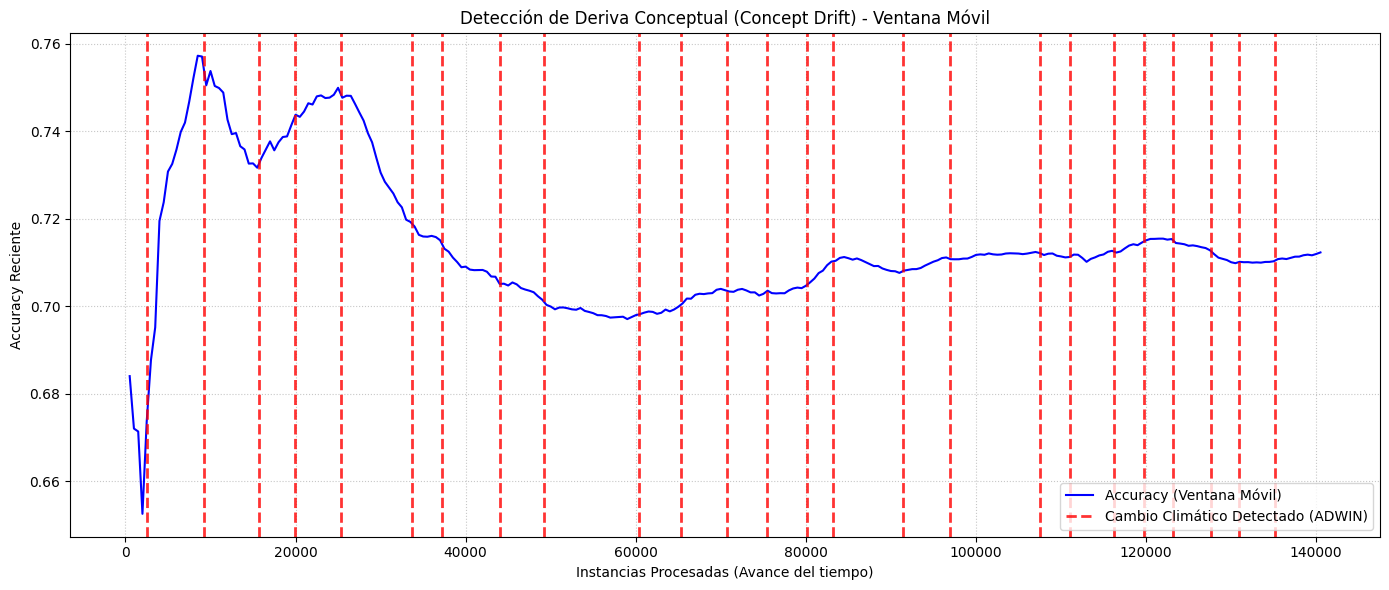

In [105]:
plt.clf() 

df_graf = pd.DataFrame(historial_accuracy, columns=['Instancia', 'RollingAccuracy'])

plt.figure(figsize=(14, 6))

# Dibujamos el accuracy
plt.plot(df_graf['Instancia'], df_graf['RollingAccuracy'], label='Accuracy (Ventana Móvil)', color='blue')

# Dibujamos las derivas (ahora serán muchas menos y más claras)
for d_idx in instancias_drifts:
    plt.axvline(x=d_idx, color='red', linestyle='--', linewidth=2, alpha=0.8, 
                label='Cambio Climático Detectado (ADWIN)' if d_idx == instancias_drifts[0] else "")

plt.title('Detección de Deriva Conceptual (Concept Drift) - Ventana Móvil')
plt.xlabel('Instancias Procesadas (Avance del tiempo)')
plt.ylabel('Accuracy Reciente')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Ejercicio 4: CLústers

In [160]:
X_clus = df[columnas_numericas]

In [198]:
columnas_numericas = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 
    'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 
    'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm',
    'RainToday'
]


preprocesamiento_clustering = (
    preprocessing.StatImputer(*[(col, stats.Mean()) for col in columnas_numericas]) | 
    preprocessing.StandardScaler()
)

# n_clusters=3 (Buscamos días: Muy Buenos, Regulares, Malos)

modelo_cluster_1 = cluster.KMeans(
    n_clusters=3,
    halflife=0.4,
    sigma=3,
    seed=42
)

modelo_cluster_2 = cluster.CluStream(
    n_macro_clusters=3, 
    max_micro_clusters=50, 
    time_window=1000, 
    seed=42
)

In [ ]:
# 3. BUCLE DE ENTRENAMIENTO ONLINE

# Diccionarios seguros para evitar KeyErrors con clusters dinámicos
pureza_m1 = defaultdict(lambda: {0: 0, 1: 0})
pureza_m2 = defaultdict(lambda: {0: 0, 1: 0})
clusters_asignados_m1 = [] # Guardaremos las predicciones para la gráfica final
clusters_asignados_m2 = [] # Guardaremos las predicciones para la gráfica final

total_instancias = len(df)
print(f"\n--- INICIANDO CLUSTERING ({total_instancias} instancias) ---")

for i, (x, _) in tqdm(enumerate(stream.iter_pandas(X_clus, y)), total=n_samples):

    y_real = y.iloc[i] 
    if pd.isna(y_real): continue # Ignoramos filas sin etiqueta real
    y_real = int(y_real)
    
    # TRADUCCIÓN PANDAS -> RIVER: Mantenemos claves, pero pasamos NaN a None
    x_clean = {k: (None if pd.isna(v) else v) for k, v in x.items()}
    
    # 1. Preprocesar
    preprocesamiento_clustering.learn_one(x_clean) 
    x_prep = preprocesamiento_clustering.transform_one(x_clean)
    
    # 2. Asignar Cluster (Test)
    cluster_1 = modelo_cluster_1.predict_one(x_prep)
    cluster_2 = modelo_cluster_2.predict_one(x_prep)
    
    # Guardamos el ID para el mapa de calor (usamos modelo_cluster_1 como referencia)
    clusters_asignados_m1.append(cluster_1)
    clusters_asignados_m2.append(cluster_2)
    
    # Anotar métricas de pureza
    if cluster_1 is not None: pureza_m1[cluster_1][y_real] += 1
    if cluster_2 is not None: pureza_m2[cluster_2][y_real] += 1
    
    # 3. Aprender (Train)
    modelo_cluster_1.learn_one(x_prep)
    modelo_cluster_2.learn_one(x_prep)
    

print("¡Clustering completado!")


--- INICIANDO CLUSTERING (140787 instancias) ---


100%|██████████| 140787/140787 [15:48<00:00, 148.39it/s]

¡Clustering completado!


In [200]:
# ==========================================
# 4. EVALUACIÓN EXTERNA (PUREZA DE CLUSTERS)
# ==========================================
def imprimir_pureza(nombre_modelo, pureza_dict):
    print(f"\n=== DISTRIBUCIÓN {nombre_modelo} ===")
    for c_id, conteos in sorted(pureza_dict.items()):
        total = conteos[0] + conteos[1]
        if total > 0:
            pct_lluvia = (conteos[1] / total) * 100
            print(f"Cluster {c_id}: {total} días agrupados -> {pct_lluvia:.1f}% de Lluvia.")

imprimir_pureza("K-MEANS ONLINE", pureza_m1)
imprimir_pureza("CLUSTREAM", pureza_m2)


=== DISTRIBUCIÓN K-MEANS ONLINE ===
Cluster 0: 79694 días agrupados -> 21.8% de Lluvia.
Cluster 1: 61093 días agrupados -> 22.6% de Lluvia.

=== DISTRIBUCIÓN CLUSTREAM ===
Cluster 0: 34137 días agrupados -> 23.0% de Lluvia.
Cluster 1: 50086 días agrupados -> 21.7% de Lluvia.
Cluster 2: 56564 días agrupados -> 22.0% de Lluvia.


In [201]:
df_centroides

,Humidity9am,Pressure3pm,RainToday,Rainfall,WindSpeed3pm,Humidity3pm,Temp3pm,MaxTemp,WindSpeed9am,WindGustSpeed,Pressure9am,MinTemp,Temp9am
0,1.238095,0.530626,1.862693,5.472748,0.177086,1.745304,-0.742941,-0.772878,0.828721,0.641731,0.283761,0.089968,-0.254023
1,0.152433,1.021958,-0.311782,-0.239955,-0.714984,0.235897,-1.068976,-1.087939,-0.273484,-0.220352,1.108633,-1.243703,-1.361358
2,0.880596,1.261807,1.831113,1.225450,0.274718,1.079018,-0.639880,-0.703052,0.241334,0.305977,1.107121,0.038130,-0.347289
3,-0.679381,0.096888,-0.353459,-0.225537,-0.139265,-0.536281,0.337202,0.351088,-0.189346,-0.313072,0.220890,-0.069167,0.139759


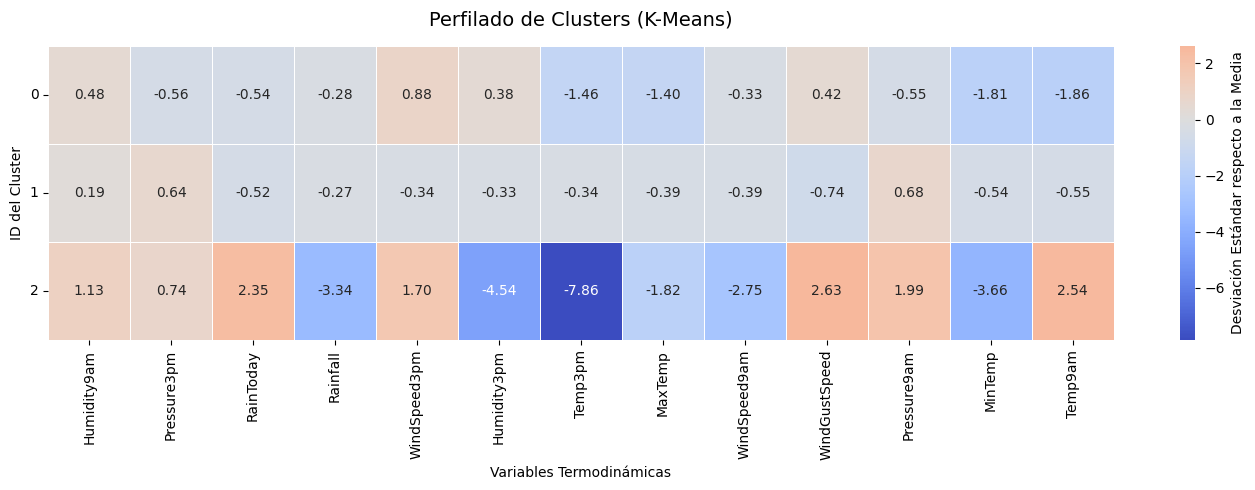

In [202]:
# 1. Extraemos los centroides internos del modelo_cluster_1 (KMeans)
# River guarda esto en un diccionario interno llamado 'centers'
centroides = modelo_cluster_1.centers

# 2. Lo convertimos en un DataFrame de Pandas para poder pintarlo
# Usamos .T (Transposición) para que las filas sean los Clusters (0, 1, 2) 
# y las columnas sean las variables meteorológicas.
df_centroides = pd.DataFrame(centroides).T

# 3. Generamos el Mapa de Calor (Heatmap)
plt.figure(figsize=(14, 5))

# Usamos 'coolwarm' (Rojo para valores altos, Azul para valores bajos)
# center=0 asegura que el blanco sea exactamente la media normal
sns.heatmap(df_centroides, annot=True, fmt=".2f", cmap='coolwarm', center=0, 
            linewidths=.5, cbar_kws={"label": "Desviación Estándar respecto a la Media"})

plt.title('Perfilado de Clusters (K-Means)', fontsize=14, pad=15)
plt.xlabel('Variables Termodinámicas')
plt.ylabel('ID del Cluster')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

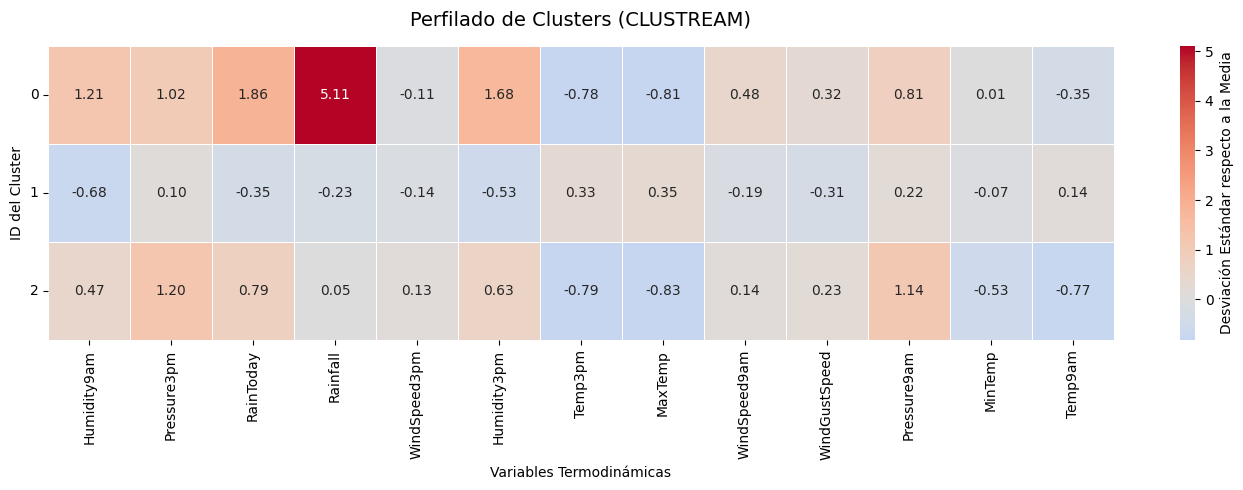

In [203]:
# 1. Extraemos los centroides internos del modelo_cluster_1 (KMeans)
# River guarda esto en un diccionario interno llamado 'centers'
centroides = modelo_cluster_2.centers

# 2. Lo convertimos en un DataFrame de Pandas para poder pintarlo
# Usamos .T (Transposición) para que las filas sean los Clusters (0, 1, 2) 
# y las columnas sean las variables meteorológicas.
df_centroides = pd.DataFrame(centroides).T

# 3. Generamos el Mapa de Calor (Heatmap)
plt.figure(figsize=(14, 5))

# Usamos 'coolwarm' (Rojo para valores altos, Azul para valores bajos)
# center=0 asegura que el blanco sea exactamente la media normal
sns.heatmap(df_centroides, annot=True, fmt=".2f", cmap='coolwarm', center=0, 
            linewidths=.5, cbar_kws={"label": "Desviación Estándar respecto a la Media"})

plt.title('Perfilado de Clusters (CLUSTREAM)', fontsize=14, pad=15)
plt.xlabel('Variables Termodinámicas')
plt.ylabel('ID del Cluster')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()